<a href="https://colab.research.google.com/github/abhinav7056/Celebal-Technolgies-Internship/blob/main/week4_Abhinav_Garg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [3]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


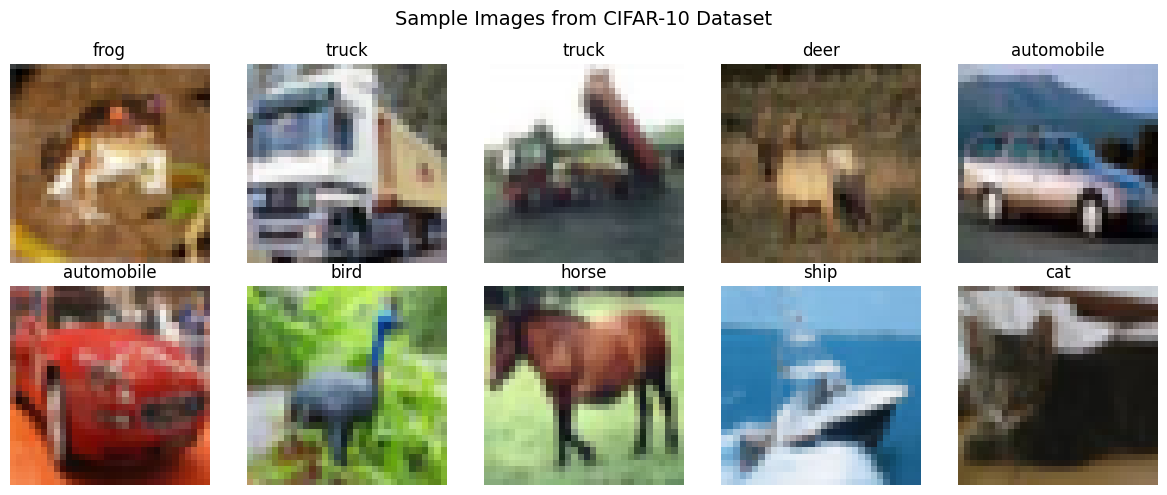

In [4]:
plt.figure(figsize=(12,5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.suptitle("Sample Images from CIFAR-10 Dataset",
             fontsize=14)

plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [5]:
x_train_norm = x_train.astype('float32') / 255.0
x_test_norm = x_test.astype('float32') / 255.0

print("Normalized Train Shape:", x_train_norm.shape)
print("Normalized Test Shape:", x_test_norm.shape)

Normalized Train Shape: (50000, 32, 32, 3)
Normalized Test Shape: (10000, 32, 32, 3)


# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
x_train_flat = x_train_norm.reshape(
    len(x_train_norm), -1
)

x_test_flat = x_test_norm.reshape(
    len(x_test_norm), -1
)

print("Train shape:", x_train_flat.shape)
print("Test shape:", x_test_flat.shape)

Train shape: (50000, 3072)
Test shape: (10000, 3072)


In [11]:
ann_model = models.Sequential([
    layers.Input(shape=(3072,)),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat,
    y_train,
    epochs=5,
    validation_split=0.1,
    batch_size=256
)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.2306 - loss: 2.1369 - val_accuracy: 0.3204 - val_loss: 1.9315
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.3258 - loss: 1.8882 - val_accuracy: 0.3604 - val_loss: 1.8187
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3473 - loss: 1.8228 - val_accuracy: 0.3680 - val_loss: 1.7740
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 37ms/step - accuracy: 0.3622 - loss: 1.7850 - val_accuracy: 0.3912 - val_loss: 1.7298
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3747 - loss: 1.7539 - val_accuracy: 0.4080 - val_loss: 1.6986


In [12]:
ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4065 - loss: 1.6762
ANN Test Accuracy: 0.4065000116825104



#### **Increase ANN Layers**


In [13]:
ann_model2 = models.Sequential([

    layers.Input(shape=(3072,)),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.2),

    layers.Dense(10, activation='softmax')
])

ann_model2.compile(
    optimizer=optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

ann_history2 = ann_model2.fit(
    x_train_flat,
    y_train,
    epochs=10,            # reduced from 20
    validation_split=0.1,
    batch_size=256,       # much faster
    callbacks=[early_stopping2]
)

Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 14s 73ms/step - accuracy: 0.2578 - loss: 2.0469 - val_accuracy: 0.3576 - val_loss: 1.8235
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.3336 - loss: 1.8476 - val_accuracy: 0.3702 - val_loss: 1.7748
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 68ms/step - accuracy: 0.3522 - loss: 1.7965 - val_accuracy: 0.3976 - val_loss: 1.6992
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.3710 - loss: 1.7542 - val_accuracy: 0.4030 - val_loss: 1.6712
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.3830 - loss: 1.7244 - val_accuracy: 0.4228 - val_loss: 1.6584
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 12s 69ms/step - accuracy: 0.3896 - loss: 1.7045 - val_accuracy: 0.4274 - val_loss: 1.6110
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.3965 - loss: 1.6828 - val_accuracy: 0.4398 - val_loss: 1.6076
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.4030 - loss: 1.6585 - 

In [14]:
ann_test_loss2, ann_test_acc2 = ann_model2.evaluate(x_test_flat, y_test)
print("ANN Test Accuracy:", ann_test_acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.4561 - loss: 1.5522
ANN Test Accuracy: 0.4560999870300293


# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [ ]:
cnn_model = models.Sequential([

    layers.Input(shape=(32,32,3)),

    layers.Conv2D(
        32, (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64, (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    # Block 3
    layers.Conv2D(
        128, (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),
    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

cnn_history = cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=12,
    validation_split=0.1,
    batch_size=256,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 153s 853ms/step - accuracy: 0.4528 - loss: 1.4996 - val_accuracy: 0.1044 - val_loss: 3.3308 - learning_rate: 0.0010
Epoch 2/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 158s 901ms/step - accuracy: 0.5971 - loss: 1.1198 - val_accuracy: 0.1602 - val_loss: 4.2861 - learning_rate: 0.0010
Epoch 3/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 152s 862ms/step - accuracy: 0.6629 - loss: 0.9530 - val_accuracy: 0.4212 - val_loss: 1.9095 - learning_rate: 0.0010
Epoch 4/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 204s 875ms/step - accuracy: 0.7039 - loss: 0.8434 - val_accuracy: 0.6126 - val_loss: 1.0607 - learning_rate: 0.0010
Epoch 5/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 201s 870ms/step - accuracy: 0.7360 - loss: 0.7555 - val_accuracy: 0.5750 - val_loss: 1.2952 - learning_rate: 0.0010
Epoch 6/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 156s 885ms/step - accuracy: 0.7602 - loss: 0.6842 - val_accuracy: 0.6392 - val_loss: 1.1157 - learning_rate: 0.0010
Epoch 7/12
176/176 ━━━━━━━━━━━━━━━━━━━━ 199s 867ms/step - accura

In [17]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - accuracy: 0.7707 - loss: 0.6796
CNN Test Accuracy: 0.7706999778747559


#### **Change CNN filters from 32→64→128 and Early Stoping**

In [18]:
cnn_model2 = models.Sequential([

    layers.Input(shape=(32,32,3)),

    layers.Conv2D(
        32, (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64, (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        128, (3,3),
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),
    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])

cnn_model2.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stopping2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-6
)

cnn_history2 = cnn_model2.fit(
    x_train_norm,
    y_train,
    epochs=15,
    validation_split=0.1,
    batch_size=256,
    callbacks=[
        early_stopping2,
        reduce_lr
    ]
)

Epoch 1/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 165s 913ms/step - accuracy: 0.4513 - loss: 1.5082 - val_accuracy: 0.0956 - val_loss: 3.3929 - learning_rate: 0.0010
Epoch 2/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 208s 944ms/step - accuracy: 0.6060 - loss: 1.1087 - val_accuracy: 0.2078 - val_loss: 3.8217 - learning_rate: 0.0010
Epoch 3/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 189s 874ms/step - accuracy: 0.6659 - loss: 0.9464 - val_accuracy: 0.4614 - val_loss: 1.5079 - learning_rate: 0.0010
Epoch 4/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 157s 894ms/step - accuracy: 0.7116 - loss: 0.8273 - val_accuracy: 0.6756 - val_loss: 0.8954 - learning_rate: 0.0010
Epoch 5/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 152s 863ms/step - accuracy: 0.7406 - loss: 0.7415 - val_accuracy: 0.6236 - val_loss: 1.1217 - learning_rate: 0.0010
Epoch 6/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 152s 867ms/step - accuracy: 0.7654 - loss: 0.6738 - val_accuracy: 0.7226 - val_loss: 0.7935 - learning_rate: 0.0010
Epoch 7/15
176/176 ━━━━━━━━━━━━━━━━━━━━ 206s 890ms/step - accura

In [19]:
cnn_test_loss2, cnn_test_acc2 = cnn_model2.evaluate(x_test_norm, y_test)
print("Improved CNN2 Test Accuracy:", cnn_test_acc2)

313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 39ms/step - accuracy: 0.7877 - loss: 0.6551
Improved CNN2 Test Accuracy: 0.7876999974250793


## 📈 Compare Learning Curves

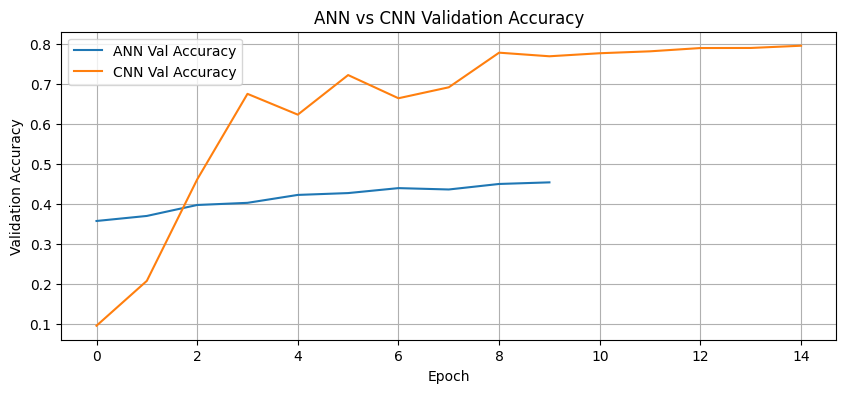

In [20]:
plt.figure(figsize=(10,4))

plt.plot(
    ann_history2.history['val_accuracy'],
    label='ANN Val Accuracy'
)

plt.plot(
    cnn_history2.history['val_accuracy'],
    label='CNN Val Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

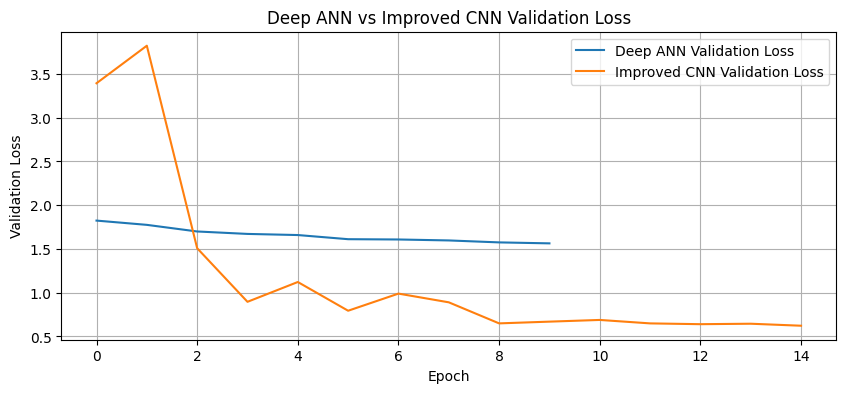

In [21]:
plt.figure(figsize=(10,4))

plt.plot(
    ann_history2.history['val_loss'],
    label='Deep ANN Validation Loss'
)

plt.plot(
    cnn_history2.history['val_loss'],
    label='Improved CNN Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.title("Deep ANN vs Improved CNN Validation Loss")

plt.legend()
plt.grid(True)

plt.show()

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [26]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

aug_cnn_model = models.Sequential([

    data_augmentation,

    layers.Conv2D(
        32, 3,
        padding='same',
        activation='relu',
        input_shape=(32,32,3)
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        64, 3,
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(
        128, 3,
        padding='same',
        activation='relu'
    ),
    layers.BatchNormalization(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation='relu'
    ),
    layers.Dropout(0.3),

    layers.Dense(
        10,
        activation='softmax'
    )
])


aug_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2
)

aug_history = aug_cnn_model.fit(
    x_train_norm,
    y_train,
    epochs=8,
    validation_split=0.1,
    batch_size=256,
    callbacks=[
        early_stop,
        reduce_lr
    ]
)

Epoch 1/8
176/176 ━━━━━━━━━━━━━━━━━━━━ 173s 958ms/step - accuracy: 0.4076 - loss: 1.6255 - val_accuracy: 0.1402 - val_loss: 3.3606 - learning_rate: 0.0010
Epoch 2/8
176/176 ━━━━━━━━━━━━━━━━━━━━ 165s 939ms/step - accuracy: 0.5217 - loss: 1.3255 - val_accuracy: 0.1882 - val_loss: 4.5789 - learning_rate: 0.0010
Epoch 3/8
176/176 ━━━━━━━━━━━━━━━━━━━━ 210s 983ms/step - accuracy: 0.5724 - loss: 1.1951 - val_accuracy: 0.4658 - val_loss: 1.5746 - learning_rate: 0.0010
Epoch 4/8
176/176 ━━━━━━━━━━━━━━━━━━━━ 201s 978ms/step - accuracy: 0.6028 - loss: 1.1146 - val_accuracy: 0.5598 - val_loss: 1.2942 - learning_rate: 0.0010
Epoch 5/8
176/176 ━━━━━━━━━━━━━━━━━━━━ 165s 938ms/step - accuracy: 0.6332 - loss: 1.0367 - val_accuracy: 0.5638 - val_loss: 1.4285 - learning_rate: 0.0010
Epoch 6/8
176/176 ━━━━━━━━━━━━━━━━━━━━ 169s 959ms/step - accuracy: 0.6512 - loss: 0.9900 - val_accuracy: 0.5916 - val_loss: 1.1690 - learning_rate: 0.0010
Epoch 7/8
176/176 ━━━━━━━━━━━━━━━━━━━━ 164s 932ms/step - accuracy: 0.6

# 📊 Final Comparison Table

In [27]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy (%)": [
        ann_test_acc * 100,
        cnn_test_acc * 100
    ]
})

comparison = comparison.round(2)

comparison

,Model,Test Accuracy (%)
0,ANN,40.65
1,CNN,77.07


In [28]:
comparison2 = pd.DataFrame({
    "Model": [
        "Deep ANN",
        "Improved CNN"
    ],
    "Test Accuracy (%)": [
        ann_test_acc2 * 100,
        cnn_test_acc2 * 100
    ]
})

comparison2 = comparison2.round(2)

comparison2

,Model,Test Accuracy (%)
0,Deep ANN,45.61
1,Improved CNN,78.77


# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
* **ANN works, but ignores image structure:** This project demonstrates the effectiveness of deep learning techniques for image classification using the CIFAR-10 dataset. Through a comparative analysis of Artificial Neural Networks (ANNs) and Convolutional Neural Networks (CNNs), it was observed that while ANNs can perform image classification, they are limited by their inability to preserve and learn spatial relationships within images.
* **CNN extracts spatial features, so it performs significantly better:** In contrast, CNNs are specifically designed to process image data and effectively extract hierarchical spatial features such as edges, textures, shapes, and object patterns. As a result, CNNs achieved significantly better classification performance and generalization compared to traditional ANN architectures.
* **Training strategies like dropout, batch norm, and augmentation improve results:** Furthermore, the incorporation of advanced training techniques, including Dropout, Batch Normalization, Data Augmentation, and Early Stopping, contributed to improved model stability, reduced overfitting, and enhanced predictive performance. These optimization strategies enabled the model to learn more robust feature representations and perform more effectively on unseen data.
* This project builds strong fundamentals for **computer vision interviews and deep learning projects:** Overall, this project provides practical experience in image preprocessing, neural network design, model evaluation, and performance optimization. It establishes a strong foundation in computer vision and deep learning concepts, making it valuable preparation for technical interviews, academic research, and real-world machine learning applications.